# ORACLE — MIRAGE Benchmark EDA

MIRAGE — 7,663 medical QA questions across 5 source datasets (Xiong et al., 2024).  
Primary RAG evaluation framework for ORACLE pipeline.  
Composition: medqa (1,273), medmcqa (4,183), pubmedqa (500), bioasq (618), mmlu (1,089).

In [1]:
import sys
import os
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mirage_loader import load_mirage

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
os.makedirs('../figures/eda', exist_ok=True)

SOURCE_COLORS = ['#5cb85c', 'steelblue', 'coral', '#f0ad4e', '#9b59b6']
SOURCE_ORDER = ['medqa', 'medmcqa', 'pubmedqa', 'bioasq', 'mmlu']
print('Imports complete')

Imports complete


In [2]:
result = load_mirage()

frames = []
for ds_name, ds_data in result.items():
    if ds_name == 'metadata':
        continue
    df_split = ds_data['data'].copy()
    df_split['source'] = ds_name
    frames.append(df_split)
df = pd.concat(frames, ignore_index=True)

df['q_len'] = df['question'].astype(str).str.len()
df['n_options'] = df['options'].apply(lambda x: len(x) if isinstance(x, dict) else 0)
df['answer_type'] = df['n_options'].map({2: 'binary', 3: 'three-way', 4: 'four-way'})

print(f'Shape: {df.shape}')
print(f'Total records: {len(df):,}')
print(df['source'].value_counts())

Loading MIRAGE benchmark...
  Source: https://raw.githubusercontent.com/Teddy-XiongGZ/MIRAGE/main/benchmark.json


  medqa: 1,273 questions
  medmcqa: 4,183 questions
  pubmedqa: 500 questions
  bioasq: 618 questions
  mmlu: 1,089 questions

MIRAGE loaded: 7,663 total questions
Shape: (7663, 10)
Total records: 7,663
source
medmcqa     4183
medqa       1273
mmlu        1089
bioasq       618
pubmedqa     500
Name: count, dtype: int64


## 1. Dataset Composition — 5 Source Splits

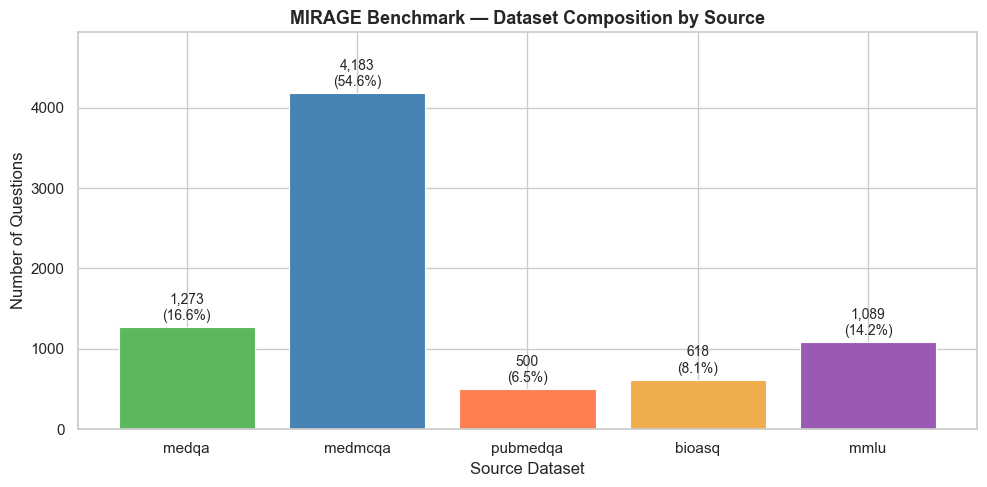

Fig 1 saved — mirage_composition.png


In [3]:
source_counts = df['source'].value_counts().reindex(SOURCE_ORDER)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(SOURCE_ORDER, source_counts.values, color=SOURCE_COLORS, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, source_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({val/len(df):.1%})', ha='center', va='bottom', fontsize=10)
ax.set_title('MIRAGE Benchmark — Dataset Composition by Source', fontsize=13, fontweight='bold')
ax.set_xlabel('Source Dataset')
ax.set_ylabel('Number of Questions')
ax.set_ylim(0, source_counts.max() * 1.18)
plt.tight_layout()
plt.savefig('../figures/eda/mirage_composition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 1 saved — mirage_composition.png')

## 2. Answer Format by Source — Binary vs Three-Way vs Four-Way

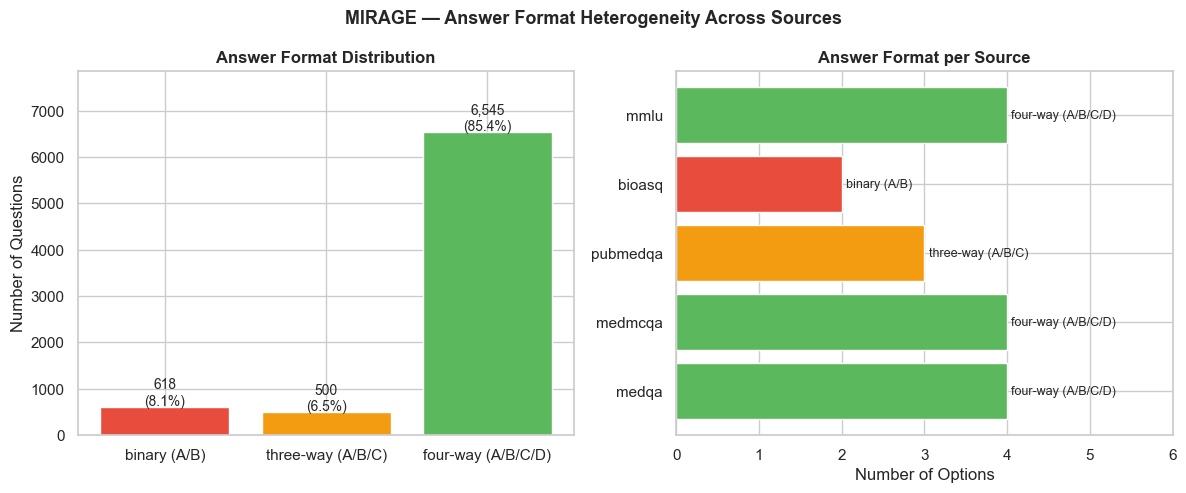

Fig 2 saved — mirage_answer_format.png


In [4]:
format_map = {2: 'binary (A/B)', 3: 'three-way (A/B/C)', 4: 'four-way (A/B/C/D)'}
format_counts = df['n_options'].value_counts().sort_index()
labels = [format_map[n] for n in format_counts.index]
counts = format_counts.values
format_colors = ['#e74c3c', '#f39c12', '#5cb85c']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(labels, counts, color=format_colors, edgecolor='white')
for i, (label, val) in enumerate(zip(labels, counts)):
    axes[0].text(i, val + 30, f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=10)
axes[0].set_title('Answer Format Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Questions')
axes[0].set_ylim(0, counts.max() * 1.2)

source_fmt = df.groupby('source')['n_options'].first().reindex(SOURCE_ORDER)
fmt_labels = [format_map.get(n, 'unknown') for n in source_fmt.values]
colors_per_source = [format_colors[{2:0,3:1,4:2}[n]] for n in source_fmt.values]
axes[1].barh(SOURCE_ORDER, source_fmt.values, color=colors_per_source, edgecolor='white')
for i, (src, n) in enumerate(zip(SOURCE_ORDER, source_fmt.values)):
    axes[1].text(n + 0.05, i, format_map.get(n,''), va='center', fontsize=9)
axes[1].set_title('Answer Format per Source', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Options')
axes[1].set_xlim(0, 6)

plt.suptitle('MIRAGE — Answer Format Heterogeneity Across Sources', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/mirage_answer_format.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 2 saved — mirage_answer_format.png')

## 3. Overall Answer Distribution — A Dominance from Binary Sources

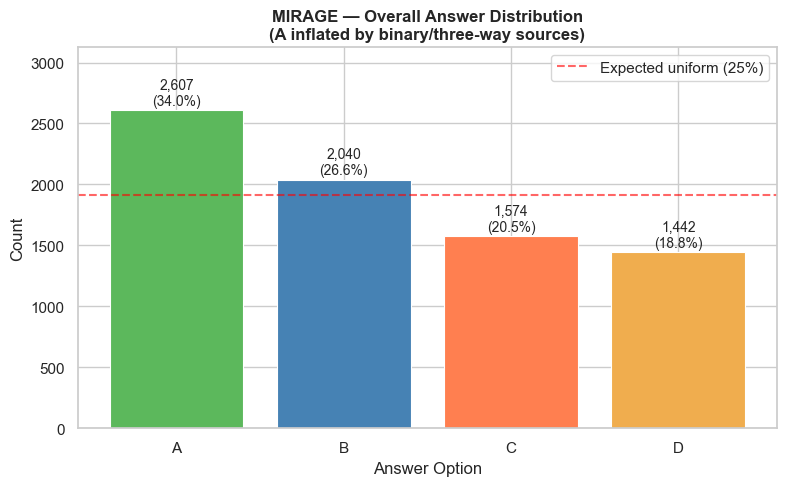

Fig 3 saved — mirage_answer_distribution.png


In [5]:
answer_counts = df['answer'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(answer_counts.index, answer_counts.values,
              color=['#5cb85c', 'steelblue', 'coral', '#f0ad4e'][:len(answer_counts)],
              edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, answer_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}\n({val/len(df):.1%})', ha='center', va='bottom', fontsize=10)
ax.axhline(len(df)/4, color='red', linestyle='--', alpha=0.6, label='Expected uniform (25%)')
ax.set_title('MIRAGE — Overall Answer Distribution\n(A inflated by binary/three-way sources)', fontsize=12, fontweight='bold')
ax.set_xlabel('Answer Option')
ax.set_ylabel('Count')
ax.legend()
ax.set_ylim(0, answer_counts.max() * 1.2)
plt.tight_layout()
plt.savefig('../figures/eda/mirage_answer_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 3 saved — mirage_answer_distribution.png')

## 4. Answer Distribution by Source — Per-Source Bias Check

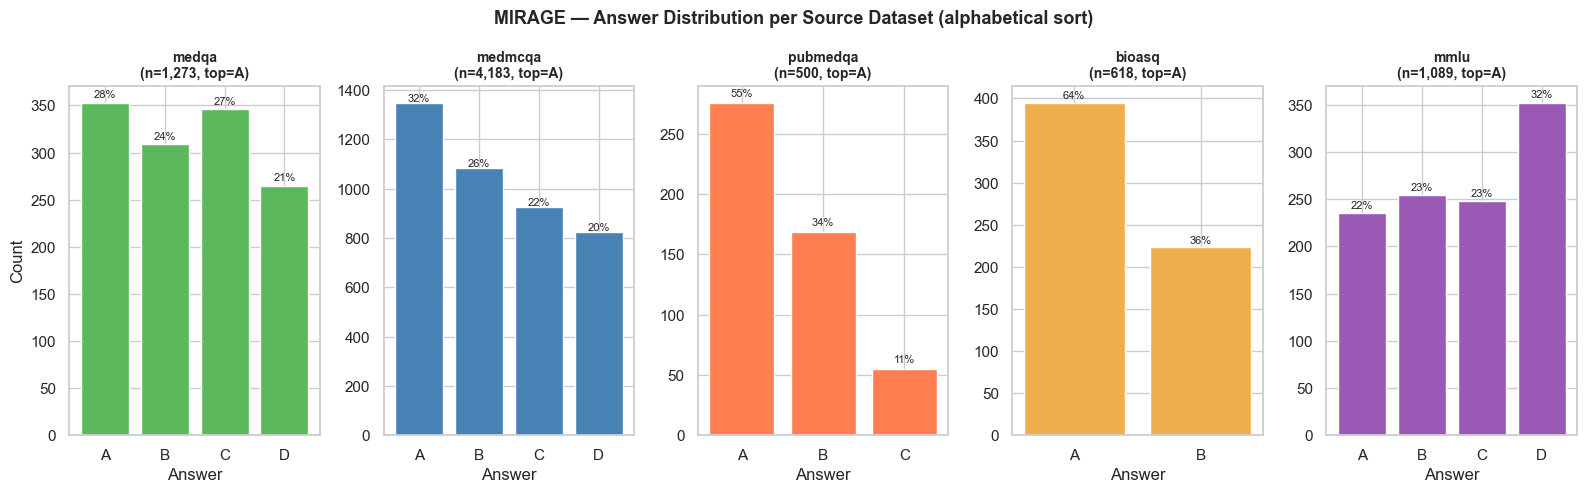

Fig 4 saved — mirage_answer_by_source.png


In [6]:
fig, axes = plt.subplots(1, 5, figsize=(16, 5))

for ax, src in zip(axes, SOURCE_ORDER):
    subset = df[df['source'] == src]
    bias = subset['answer'].value_counts().sort_index()  # alphabetical — matches script output
    ax.bar(bias.index, bias.values, color=SOURCE_COLORS[SOURCE_ORDER.index(src)], edgecolor='white')
    ax.set_title(f'{src}\n(n={len(subset):,})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Answer')
    ax.set_ylabel('Count' if src == 'medqa' else '')
    for i, (ans, val) in enumerate(bias.items()):
        ax.text(i, val + 5, f'{val/len(subset):.0%}', ha='center', fontsize=8)
    top = bias.index[0]
    ax.set_title(f'{src}\n(n={len(subset):,}, top={top})', fontsize=10, fontweight='bold')

plt.suptitle('MIRAGE — Answer Distribution per Source Dataset (alphabetical sort)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/mirage_answer_by_source.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 4 saved — mirage_answer_by_source.png')

## 5. Question Length by Source — MedQA Longest (Clinical Scenarios)

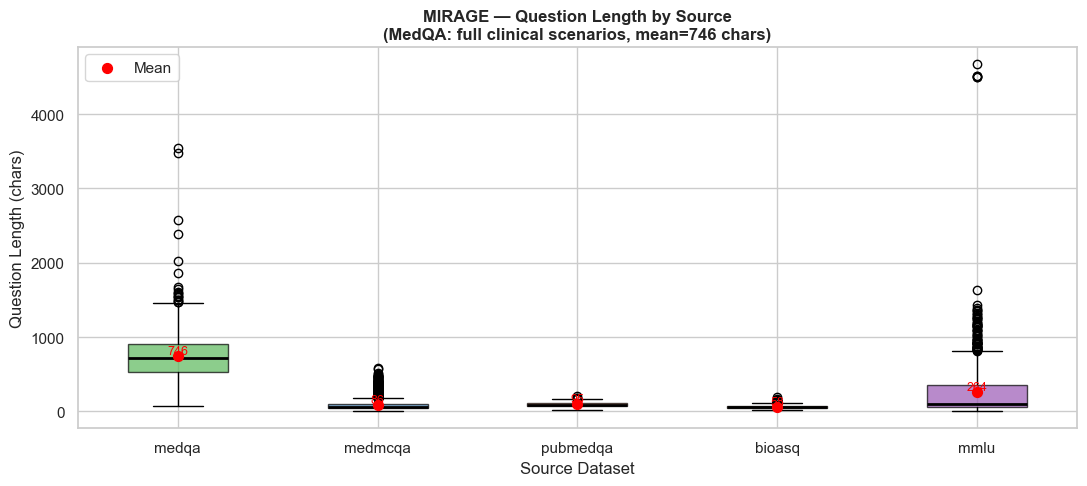

Fig 5 saved — mirage_question_length_by_source.png


In [7]:
fig, ax = plt.subplots(figsize=(11, 5))

data_by_source = [df[df['source'] == src]['q_len'].values for src in SOURCE_ORDER]
bp = ax.boxplot(data_by_source, labels=SOURCE_ORDER, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], SOURCE_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

means = [df[df['source'] == src]['q_len'].mean() for src in SOURCE_ORDER]
ax.scatter(range(1, len(SOURCE_ORDER)+1), means, color='red', zorder=5, s=50, label='Mean')
for i, (src, mean) in enumerate(zip(SOURCE_ORDER, means)):
    ax.text(i+1, mean + 30, f'{mean:.0f}', ha='center', fontsize=9, color='red')

ax.set_title('MIRAGE — Question Length by Source\n(MedQA: full clinical scenarios, mean=746 chars)', fontsize=12, fontweight='bold')
ax.set_xlabel('Source Dataset')
ax.set_ylabel('Question Length (chars)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/mirage_question_length_by_source.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 5 saved — mirage_question_length_by_source.png')

## 5b. Median vs Mean Question Length — MedQA Consistently Long (Not Outlier-Driven)

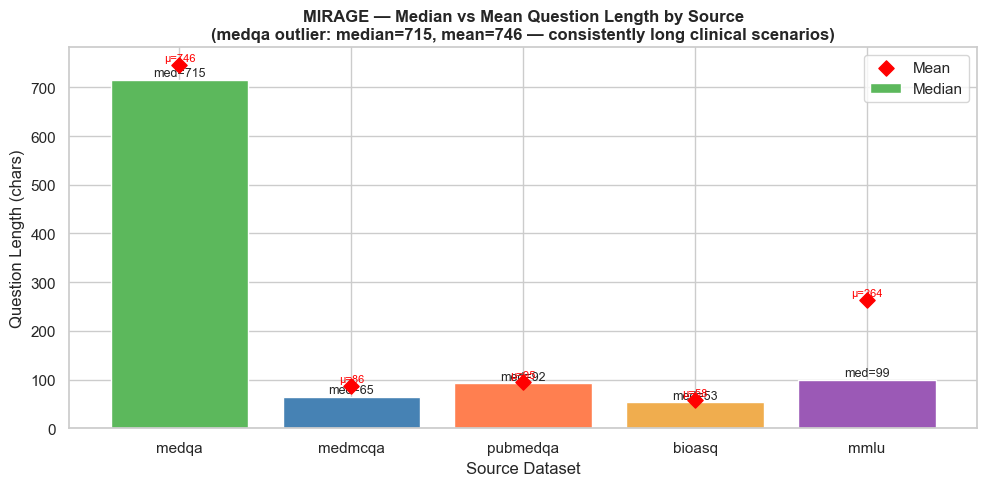

Fig 5b saved — mirage_question_length_median.png


In [8]:
# Median question length ranked by source — matches script min/max/mean/median table
medians = df.groupby('source')['q_len'].median().reindex(SOURCE_ORDER)
means = df.groupby('source')['q_len'].mean().reindex(SOURCE_ORDER)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(SOURCE_ORDER))
bars = ax.bar(x, medians.values, color=SOURCE_COLORS, edgecolor='white', label='Median')
ax.scatter(x, means.values, color='red', zorder=5, s=60, label='Mean', marker='D')
for i, (src, med, mean) in enumerate(zip(SOURCE_ORDER, medians.values, means.values)):
    ax.text(i, med + 8, f'med={med:.0f}', ha='center', fontsize=9)
    ax.text(i, mean + 8, f'μ={mean:.0f}', ha='center', fontsize=8, color='red')
ax.set_xticks(list(x))
ax.set_xticklabels(SOURCE_ORDER)
ax.set_title('MIRAGE — Median vs Mean Question Length by Source\n(medqa outlier: median=715, mean=746 — consistently long clinical scenarios)', fontsize=12, fontweight='bold')
ax.set_xlabel('Source Dataset')
ax.set_ylabel('Question Length (chars)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/mirage_question_length_median.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 5b saved — mirage_question_length_median.png')

## 6. Question Length Distribution — Heavy Right Skew from MedQA

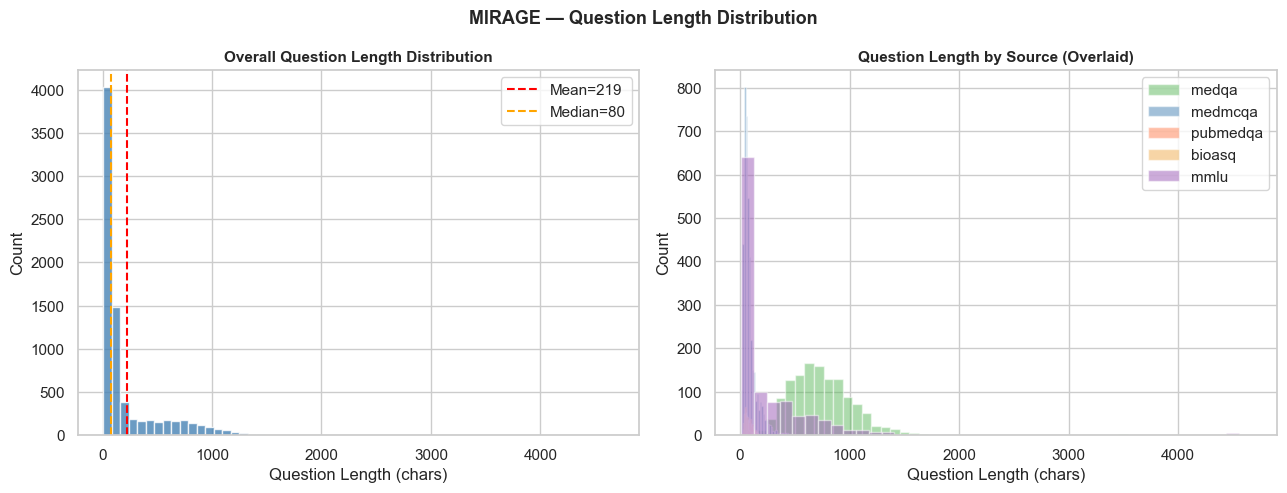

Fig 6 saved — mirage_question_length_dist.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['q_len'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['q_len'].mean(), color='red', linestyle='--', label=f'Mean={df["q_len"].mean():.0f}')
axes[0].axvline(df['q_len'].median(), color='orange', linestyle='--', label=f'Median={df["q_len"].median():.0f}')
axes[0].set_title('Overall Question Length Distribution', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Question Length (chars)')
axes[0].set_ylabel('Count')
axes[0].legend()

for src, color in zip(SOURCE_ORDER, SOURCE_COLORS):
    subset = df[df['source'] == src]['q_len']
    axes[1].hist(subset, bins=40, alpha=0.5, label=src, color=color)
axes[1].set_title('Question Length by Source (Overlaid)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Question Length (chars)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('MIRAGE — Question Length Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/mirage_question_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 6 saved — mirage_question_length_dist.png')

## 7. Option Count Distribution — Four-Way Dominates (85.4%)

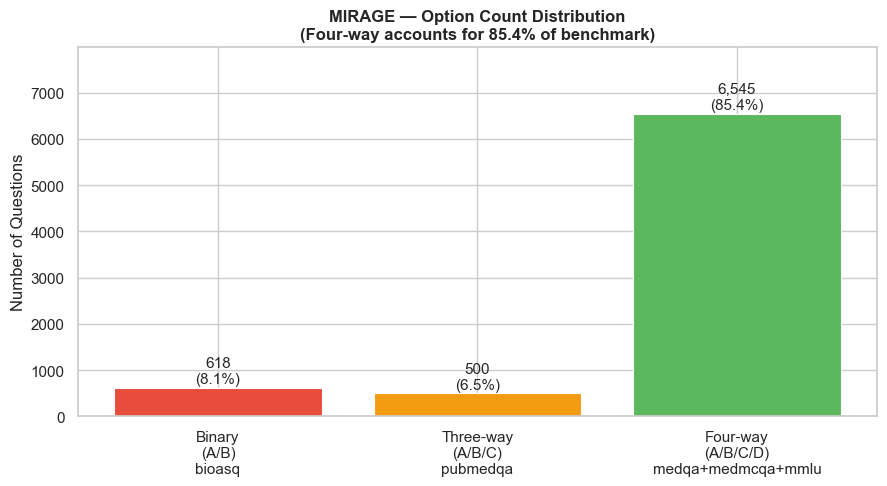

Fig 7 saved — mirage_option_count.png


In [10]:
opt_counts = df['n_options'].value_counts().sort_index()
opt_labels = {2: 'Binary\n(A/B)\nbioasq', 3: 'Three-way\n(A/B/C)\npubmedqa', 4: 'Four-way\n(A/B/C/D)\nmedqa+medmcqa+mmlu'}
labels = [opt_labels[n] for n in opt_counts.index]
opt_colors = ['#e74c3c', '#f39c12', '#5cb85c']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, opt_counts.values, color=opt_colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, opt_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(df):.1%})', ha='center', va='bottom', fontsize=11)
ax.set_title('MIRAGE — Option Count Distribution\n(Four-way accounts for 85.4% of benchmark)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Questions')
ax.set_ylim(0, opt_counts.max() * 1.22)
plt.tight_layout()
plt.savefig('../figures/eda/mirage_option_count.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 7 saved — mirage_option_count.png')

## 8. PMID Coverage — Retrieval Ground Truth Availability

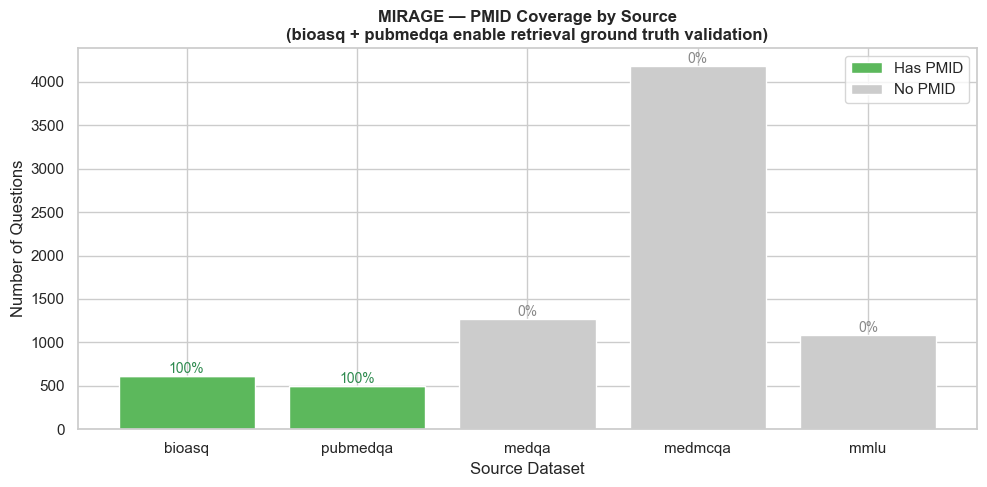

Fig 8 saved — mirage_pmid_coverage.png


In [11]:
pmid_data = {'bioasq': (618, 618), 'pubmedqa': (500, 500),
             'medqa': (1273, 0), 'medmcqa': (4183, 0), 'mmlu': (1089, 0)}

sources = list(pmid_data.keys())
totals = [pmid_data[s][0] for s in sources]
with_pmid = [pmid_data[s][1] for s in sources]
without_pmid = [t - p for t, p in zip(totals, with_pmid)]

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(sources, with_pmid, label='Has PMID', color='#5cb85c', edgecolor='white')
bars2 = ax.bar(sources, without_pmid, bottom=with_pmid, label='No PMID', color='#cccccc', edgecolor='white')

for i, src in enumerate(sources):
    pct = with_pmid[i] / totals[i]
    ax.text(i, totals[i] + 30, f'{pct:.0%}', ha='center', fontsize=10,
            color='#2d8a4e' if pct > 0 else '#888888')

ax.set_title('MIRAGE — PMID Coverage by Source\n(bioasq + pubmedqa enable retrieval ground truth validation)', fontsize=12, fontweight='bold')
ax.set_xlabel('Source Dataset')
ax.set_ylabel('Number of Questions')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/mirage_pmid_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 8 saved — mirage_pmid_coverage.png')

## 9. RAG Difficulty Proxy — MedQA Dominates Long Questions

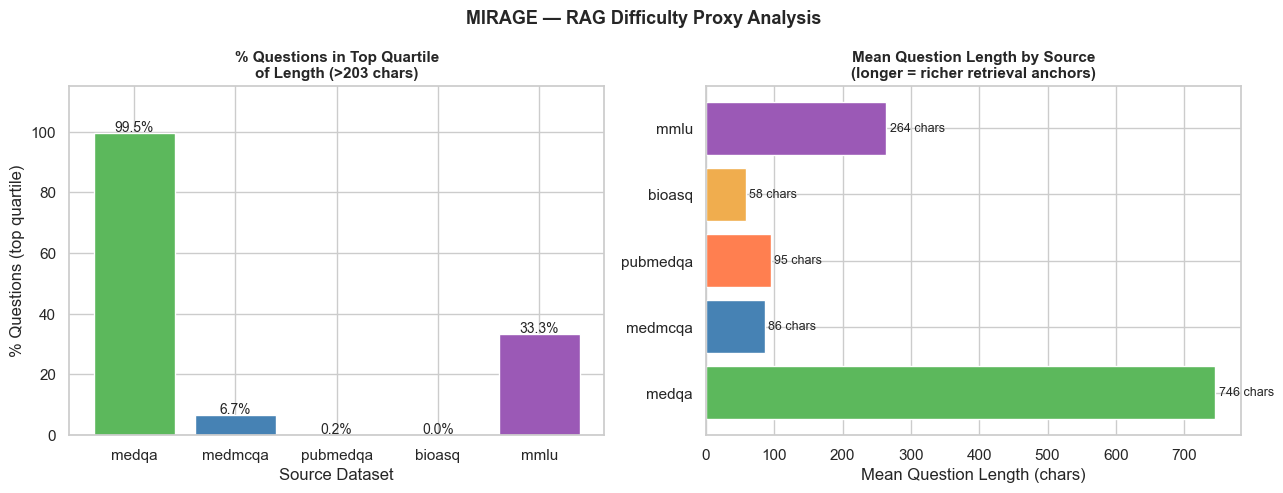

Fig 9 saved — mirage_rag_difficulty.png


In [12]:
q75 = df['q_len'].quantile(0.75)
rag_diff = {}
for src in SOURCE_ORDER:
    subset = df[df['source'] == src]
    long_q = (subset['q_len'] > q75).sum()
    rag_diff[src] = long_q / len(subset) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(list(rag_diff.keys()), list(rag_diff.values()),
            color=SOURCE_COLORS, edgecolor='white')
for i, (src, val) in enumerate(rag_diff.items()):
    axes[0].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10)
axes[0].set_title(f'% Questions in Top Quartile\nof Length (>{q75:.0f} chars)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Source Dataset')
axes[0].set_ylabel('% Questions (top quartile)')
axes[0].set_ylim(0, 115)

means = {src: df[df['source']==src]['q_len'].mean() for src in SOURCE_ORDER}
axes[1].barh(list(means.keys()), list(means.values()), color=SOURCE_COLORS, edgecolor='white')
for i, (src, val) in enumerate(means.items()):
    axes[1].text(val + 5, i, f'{val:.0f} chars', va='center', fontsize=9)
axes[1].set_title('Mean Question Length by Source\n(longer = richer retrieval anchors)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Mean Question Length (chars)')

plt.suptitle('MIRAGE — RAG Difficulty Proxy Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/mirage_rag_difficulty.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 9 saved — mirage_rag_difficulty.png')

## 10. Cross-Dataset Length Comparison — MIRAGE vs Individual Datasets

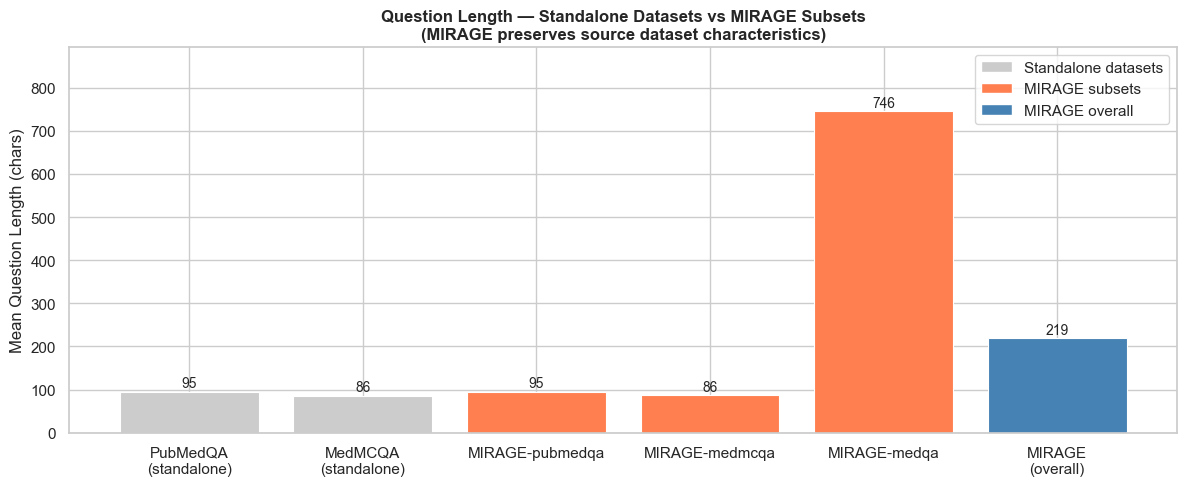

Fig 10 saved — mirage_length_comparison.png


In [13]:
dataset_means = {
    'PubMedQA\n(standalone)': 95,
    'MedMCQA\n(standalone)': 86,
    'MIRAGE-pubmedqa': df[df['source']=='pubmedqa']['q_len'].mean(),
    'MIRAGE-medmcqa': df[df['source']=='medmcqa']['q_len'].mean(),
    'MIRAGE-medqa': df[df['source']=='medqa']['q_len'].mean(),
    'MIRAGE\n(overall)': df['q_len'].mean()
}
colors = ['#cccccc','#cccccc','coral','coral','coral','steelblue']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(list(dataset_means.keys()), list(dataset_means.values()),
              color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, dataset_means.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10)
ax.set_title('Question Length — Standalone Datasets vs MIRAGE Subsets\n(MIRAGE preserves source dataset characteristics)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Question Length (chars)')
ax.set_ylim(0, max(dataset_means.values()) * 1.2)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#cccccc', label='Standalone datasets'),
                   Patch(facecolor='coral', label='MIRAGE subsets'),
                   Patch(facecolor='steelblue', label='MIRAGE overall')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('../figures/eda/mirage_length_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 10 saved — mirage_length_comparison.png')

## 11. Key Observations

- **Total: 7,663 questions** across 5 source datasets — medmcqa dominates at 54.6%
- **Three answer formats**: binary/bioasq (8.1%), three-way/pubmedqa (6.5%), four-way/medqa+medmcqa+mmlu (85.4%)
- **A-option inflation**: Overall A=34.0% — driven by bioasq (63.9% A) and pubmedqa (55.2% A) binary/three-way formats
- **MedQA questions are 8.7x longer** than bioasq (mean 746 vs 58 chars) — full clinical scenarios vs short factual queries
- **PMID ground truth available** for bioasq (100%) and pubmedqa (100%) — 1,118 questions with retrieval validation
- **MedQA = hardest RAG subset**: 99.5% of questions exceed the overall top quartile length threshold
- **MIRAGE preserves source characteristics**: MIRAGE subsets match standalone dataset lengths exactly
- **ORACLE uses MIRAGE** as end-to-end RAG evaluation — question-only retrieval setting tests full pipeline faithfulness